In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, initializers
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)


In [2]:
# =========================================================
# 0. TEXT CLEANING (fixes UnicodeDecodeError: byte 0xc2 ...)
# =========================================================
def clean_text(s):
    """
    Python-side cleaning applied BEFORE data reaches TensorFlow.

    Root cause of the original error: scraped comment data contains
    characters such as the non-breaking space (\\xa0), ©, £, ¢ etc. These are
    encoded in UTF-8 as a two-byte sequence starting with 0xC2. Keras'
    default TextVectorization standardization ('lower_and_strip_punctuation')
    operates at the byte level and can split that two-byte sequence, leaving a
    dangling 0xC2 lead byte that fails to decode ->
    "UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc2 ... unexpected end of data".

    We normalize and strip non-ASCII so no multi-byte sequence survives into
    the byte-level standardizer.
    """
    if not isinstance(s, str):
        s = str(s)
    # Normalize compatibility forms (e.g. smart quotes, full-width chars)
    s = unicodedata.normalize("NFKC", s)
    # Drop any non-ASCII bytes (this removes the 0xC2-class characters)
    s = s.encode("ascii", "ignore").decode("ascii")
    # Collapse whitespace
    s = " ".join(s.split())
    return s if s else "missing_text"


def tf_standardize(input_data):
    """
    Custom standardization run INSIDE the TextVectorization layer.

    Acts as a second line of defense: lowercases, removes any remaining
    non-ASCII bytes, strips punctuation, and collapses whitespace - all on
    well-formed strings so the layer never produces a broken byte sequence.
    """
    lowercase = tf.strings.lower(input_data)
    ascii_only = tf.strings.regex_replace(lowercase, r"[^\x00-\x7F]+", " ")
    no_punct = tf.strings.regex_replace(ascii_only, r"[^a-z0-9\s]", " ")
    return tf.strings.regex_replace(no_punct, r"\s+", " ")


In [3]:
# %%
# =========================================================
# 1. MODELING PIPELINE (Keras Native)
# =========================================================
def build_bilstm_pipeline(train_texts, num_classes=1, initial_bias=None, max_tokens=20000, output_sequence_length=150, use_meta_features=False):
    """
    Constructs a Keras model that can handle raw text, with optional tabular meta-features.
    """
    # 1. Text Vectorization
    vectorize_layer = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode='int',
        output_sequence_length=output_sequence_length,
        standardize=tf_standardize 
    )
    vectorize_layer.adapt(train_texts)
    
    if initial_bias is not None:
        output_bias = initializers.Constant(initial_bias)
    else:
        output_bias = 'zeros'

    # 2. Text Input Stream
    text_inputs = tf.keras.Input(shape=(1,), dtype=tf.string, name="text_input")
    x = vectorize_layer(text_inputs)
    x = layers.Embedding(input_dim=max_tokens, output_dim=128)(x) 
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.GlobalMaxPooling1D()(x)

    # 3. Optional Meta Feature Stream (Probabilities & Binary Label from Model 1)
    if use_meta_features:
        # Shape is 2: [Model_1_Probability, Model_1_Binary_Label]
        meta_inputs = tf.keras.Input(shape=(2,), dtype=tf.float32, name="meta_input")
        x = layers.Concatenate()([x, meta_inputs])
        inputs = [text_inputs, meta_inputs]
    else:
        inputs = text_inputs

    # 4. Dense Output Layers
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='sigmoid', bias_initializer=output_bias)(x)

    model = Model(inputs=inputs, outputs=outputs)
    
    # 5. Compile
    metrics = [tf.keras.metrics.AUC(name='auc')]
    if num_classes > 1:
        metrics = [tf.keras.metrics.AUC(name='auc', multi_label=True, num_labels=num_classes)]
        
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryFocalCrossentropy(),
        metrics=metrics
    )
    
    return model



In [4]:
# %%
# =========================================================
# 2. EVALUATION FUNCTIONS (Untouched)
# =========================================================
def get_target_recall_threshold(y_true, y_probs, target_recall=0.95):
    """Finds the highest threshold that maintains at least the target recall."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    valid_indices = np.where(recall[:-1] >= target_recall)[0]
    if len(valid_indices) == 0:
        print(f"Warning: Could not achieve {target_recall} recall. Returning lowest threshold.")
        return thresholds[0]
    best_idx = valid_indices[-1]
    return thresholds[best_idx]

def plot_threshold_curves(y_true, y_probs, class_name, dataset_name="Validation"):
    """Plots Precision, Recall, and F1 across all thresholds 0-1."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    
    f1_scores = np.divide(
        2 * (precision * recall), 
        (precision + recall), 
        out=np.zeros_like(precision), 
        where=(precision + recall) != 0
    )
    
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precision[:-1], label='Precision', color='#1f77b4', linestyle='--')
    plt.plot(thresholds, recall[:-1], label='Recall', color='#ff7f0e', linestyle='-.')
    plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='#2ca02c', linewidth=2.5)
    plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
    
    plt.title(f'[{class_name}] {dataset_name}: Metrics vs. Classification Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()
    
    return best_threshold

def plot_dual_confusion_matrix(y_val, y_val_probs, y_test, y_test_probs, class_name, threshold=0.5):
    """Side-by-side CM for Validation and Test datasets using a custom threshold."""
    y_val_pred = (y_val_probs >= threshold).astype(int)
    y_test_pred = (y_test_probs >= threshold).astype(int)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cm_val = confusion_matrix(y_val, y_val_pred)
    ConfusionMatrixDisplay(cm_val, display_labels=["Negative", "Positive"]).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"[{class_name}] Val CM (Thresh={threshold:.2f})")
    
    cm_test = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm_test, display_labels=["Negative", "Positive"]).plot(ax=axes[1], cmap='Greens', colorbar=False)
    axes[1].set_title(f"[{class_name}] Test CM (Thresh={threshold:.2f})")
    
    plt.tight_layout()
    plt.show()



In [5]:
def create_threshold_metrics_table(y_true, y_probs, step=0.05):
    """
    Generates a table of TP, FP, TN, FN across thresholds from 0 to 1.
    """
    thresholds = np.arange(0.0, 1.0 + step, step)
    results = []
    
    for t in thresholds:
        # Convert probabilities to hard labels based on current threshold t
        preds = (y_probs >= t).astype(int)
        
        # labels=[0,1] ensures it always returns a 2x2 matrix, even if preds are all 0 or all 1
        cm = confusion_matrix(y_true, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            "Threshold": f"{t:.2f}",
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn
        })
        
    df_metrics = pd.DataFrame(results)
    return df_metrics




Loading data...

🚀 [STAGE 1] Training Model 1 (Binary Toxicity Filter)...
Epoch 1/30
4999/4999 [==============================] - 232s 46ms/step - loss: 0.0426 - auc: 0.9316 - val_loss: 0.0347 - val_auc: 0.9665
Epoch 2/30
4999/4999 [==============================] - 277s 55ms/step - loss: 0.0355 - auc: 0.9549 - val_loss: 0.0366 - val_auc: 0.9661
Epoch 3/30
4999/4999 [==============================] - 217s 43ms/step - loss: 0.0327 - auc: 0.9627 - val_loss: 0.0337 - val_auc: 0.9659
Epoch 4/30
4999/4999 [==============================] - 216s 43ms/step - loss: 0.0302 - auc: 0.9689 - val_loss: 0.0359 - val_auc: 0.9642
Epoch 5/30
4999/4999 [==============================] - 226s 45ms/step - loss: 0.0276 - auc: 0.9748 - val_loss: 0.0341 - val_auc: 0.9613
Epoch 6/30
4999/4999 [==============================] - 233s 47ms/step - loss: 0.0249 - auc: 0.9797 - val_loss: 0.0406 - val_auc: 0.9586
Epoch 6: early stopping

--- Generating Model 1 Predictions ---
1563/1563 [=============================

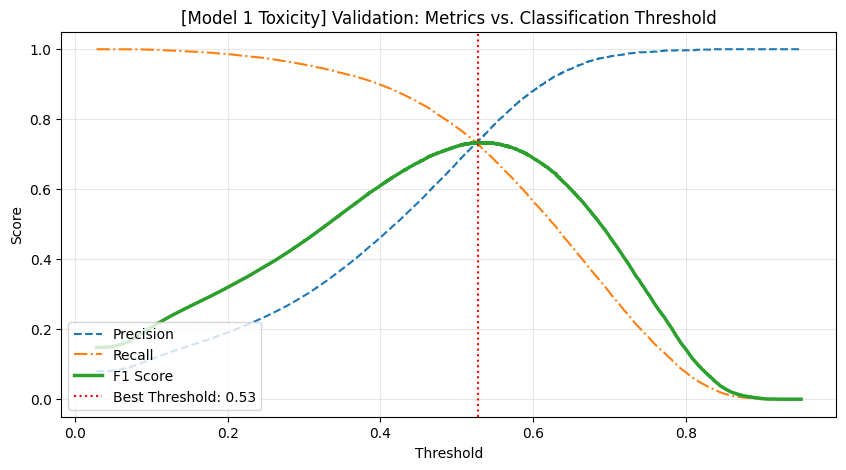

✅ Optimal F1 Threshold (used for Binary Meta-Feature): 0.5281
✅ Threshold for 95% Recall (used for Filtering Data): 0.3136
Passing 212643 / 1279689 Train cases to Model 2

🚀 [STAGE 3] Training Model 2 (Sub-labels with Multi-Input)...
Epoch 1/30
831/831 [==============================] - 44s 49ms/step - loss: 0.0509 - auc: 0.7453 - val_loss: 0.0300 - val_auc: 0.9345
Epoch 2/30
831/831 [==============================] - 43s 52ms/step - loss: 0.0390 - auc: 0.9059 - val_loss: 0.0274 - val_auc: 0.9466
Epoch 3/30
831/831 [==============================] - 42s 51ms/step - loss: 0.0355 - auc: 0.9321 - val_loss: 0.0285 - val_auc: 0.9478
Epoch 4/30
831/831 [==============================] - 41s 50ms/step - loss: 0.0331 - auc: 0.9450 - val_loss: 0.0273 - val_auc: 0.9487
Epoch 5/30
831/831 [==============================] - 41s 49ms/step - loss: 0.0304 - auc: 0.9564 - val_loss: 0.0279 - val_auc: 0.9441
Epoch 6/30
831/831 [==============================] - 40s 48ms/step - loss: 0.0281 - auc: 0.9642

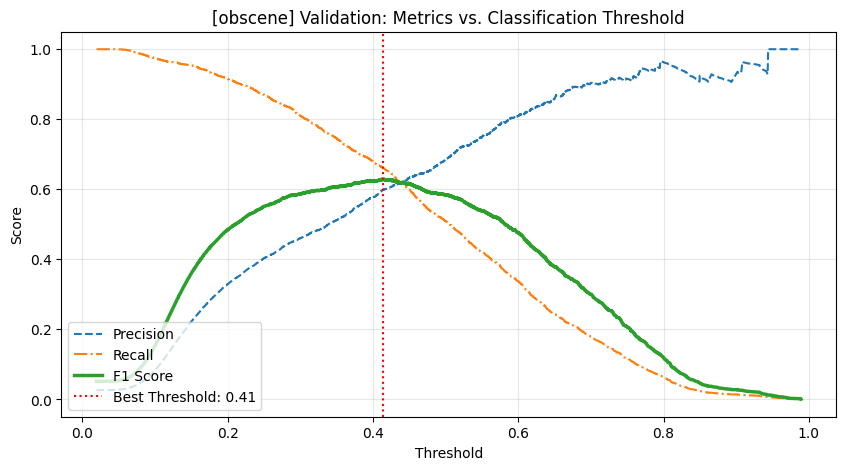


✅ Optimal F1 Threshold for obscene: 0.41


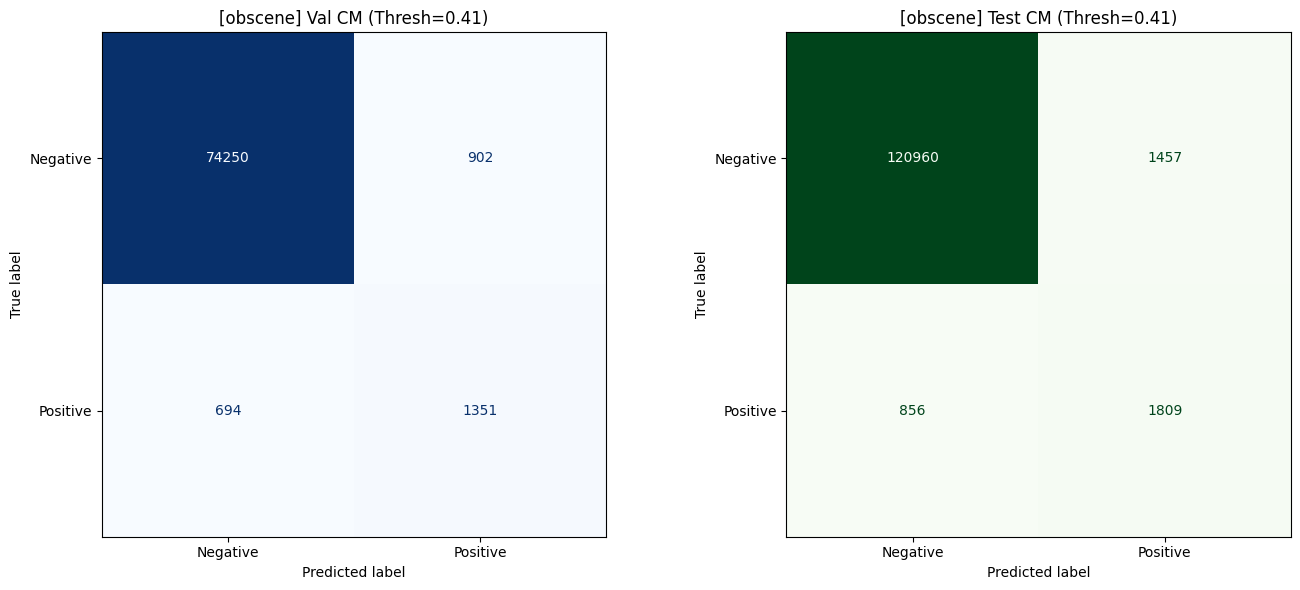


🔍 ANALYZING CLASS: SEXUAL_EXPLICIT

Metrics Table for sexual_explicit (Filtered Subset):
Threshold  TP    FP    TN  FN
     0.00 766 76431     0   0
     0.05 758 36680 39751   8
     0.10 735  6547 69884  31
     0.15 691  3222 73209  75
     0.20 644  1981 74450 122
     0.25 576  1279 75152 190
     0.30 498   850 75581 268
     0.35 430   573 75858 336
     0.40 354   362 76069 412
     0.45 289   243 76188 477
     0.50 237   149 76282 529
     0.55 193    90 76341 573
     0.60 151    57 76374 615
     0.65 115    37 76394 651
     0.70  80    18 76413 686
     0.75  59    14 76417 707
     0.80  35     5 76426 731
     0.85  19     3 76428 747
     0.90   8     0 76431 758
     0.95   1     0 76431 765
     1.00   0     0 76431 766


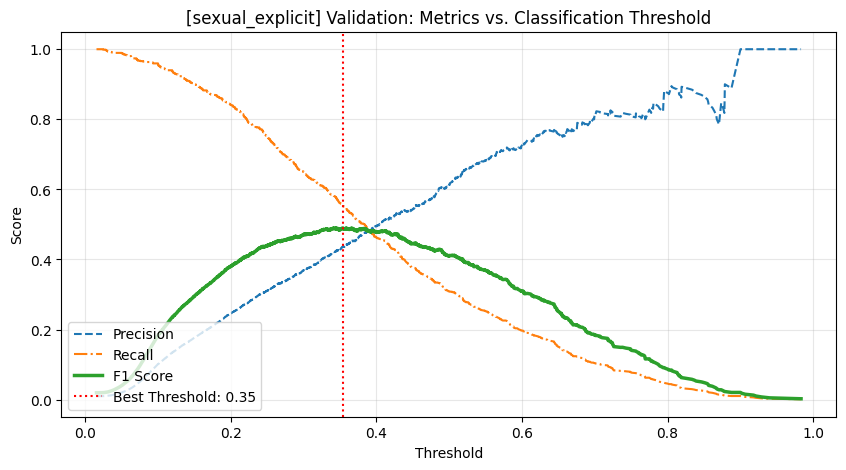


✅ Optimal F1 Threshold for sexual_explicit: 0.35


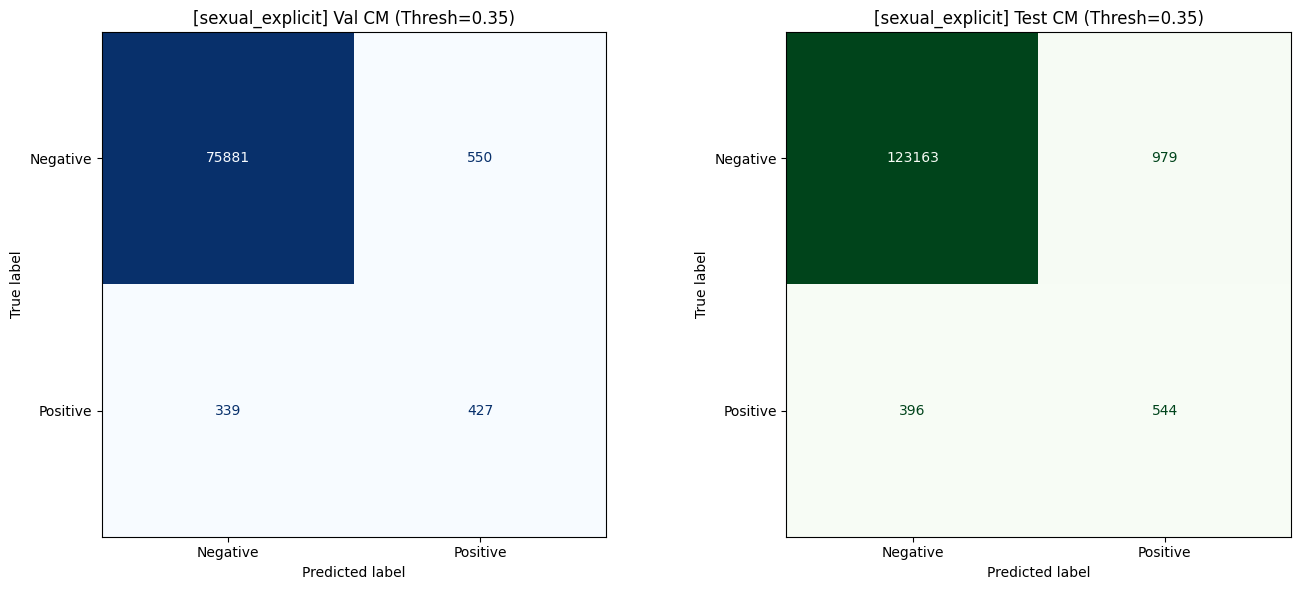


🔍 ANALYZING CLASS: IDENTITY_ATTACK

Metrics Table for identity_attack (Filtered Subset):
Threshold   TP    FP    TN   FN
     0.00 1675 75522     0    0
     0.05 1672 63475 12047    3
     0.10 1646 30418 45104   29
     0.15 1591 19678 55844   84
     0.20 1531 14807 60715  144
     0.25 1437 11090 64432  238
     0.30 1316  7855 67667  359
     0.35 1133  5089 70433  542
     0.40  921  2985 72537  754
     0.45  693  1558 73964  982
     0.50  458   720 74802 1217
     0.55  255   272 75250 1420
     0.60  121    80 75442 1554
     0.65   43     9 75513 1632
     0.70   13     0 75522 1662
     0.75    4     0 75522 1671
     0.80    3     0 75522 1672
     0.85    1     0 75522 1674
     0.90    1     0 75522 1674
     0.95    1     0 75522 1674
     1.00    0     0 75522 1675


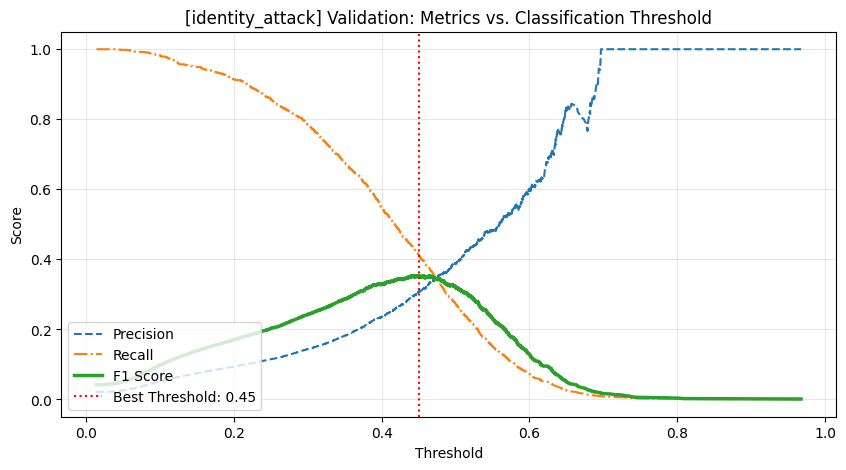


✅ Optimal F1 Threshold for identity_attack: 0.45


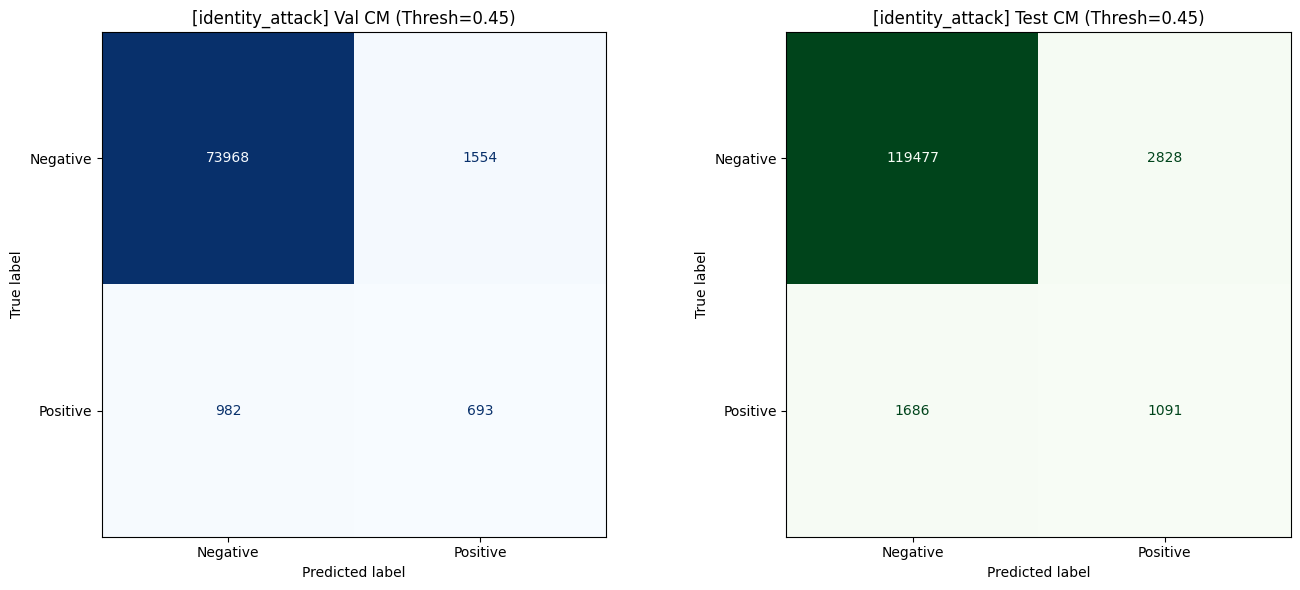


🔍 ANALYZING CLASS: INSULT

Metrics Table for insult (Filtered Subset):
Threshold    TP    FP    TN    FN
     0.00 20081 57116     0     0
     0.05 20081 57116     0     0
     0.10 20081 57114     2     0
     0.15 20077 56315   801     4
     0.20 20027 51558  5558    54
     0.25 19862 41780 15336   219
     0.30 19543 31989 25127   538
     0.35 19072 23867 33249  1009
     0.40 18383 16815 40301  1698
     0.45 17265 10310 46806  2816
     0.50 15727  5717 51399  4354
     0.55 13727  2823 54293  6354
     0.60 11223  1250 55866  8858
     0.65  8283   447 56669 11798
     0.70  5432   107 57009 14649
     0.75  3054    20 57096 17027
     0.80  1347     6 57110 18734
     0.85   384     2 57114 19697
     0.90    40     0 57116 20041
     0.95     0     0 57116 20081
     1.00     0     0 57116 20081


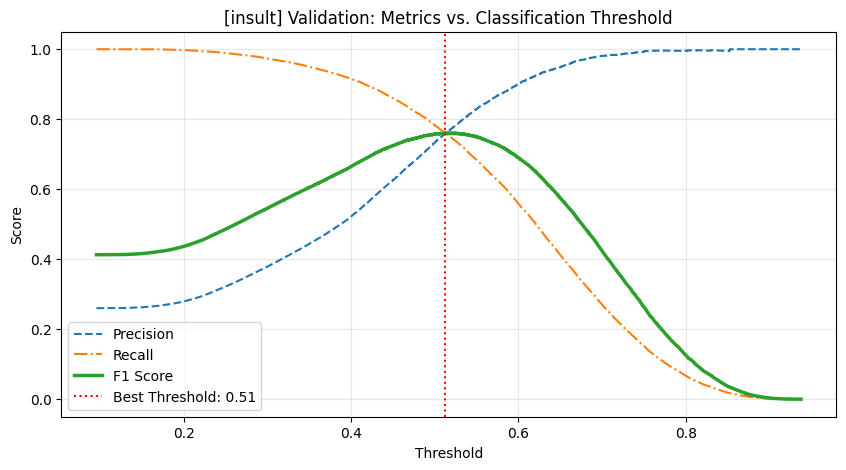


✅ Optimal F1 Threshold for insult: 0.51


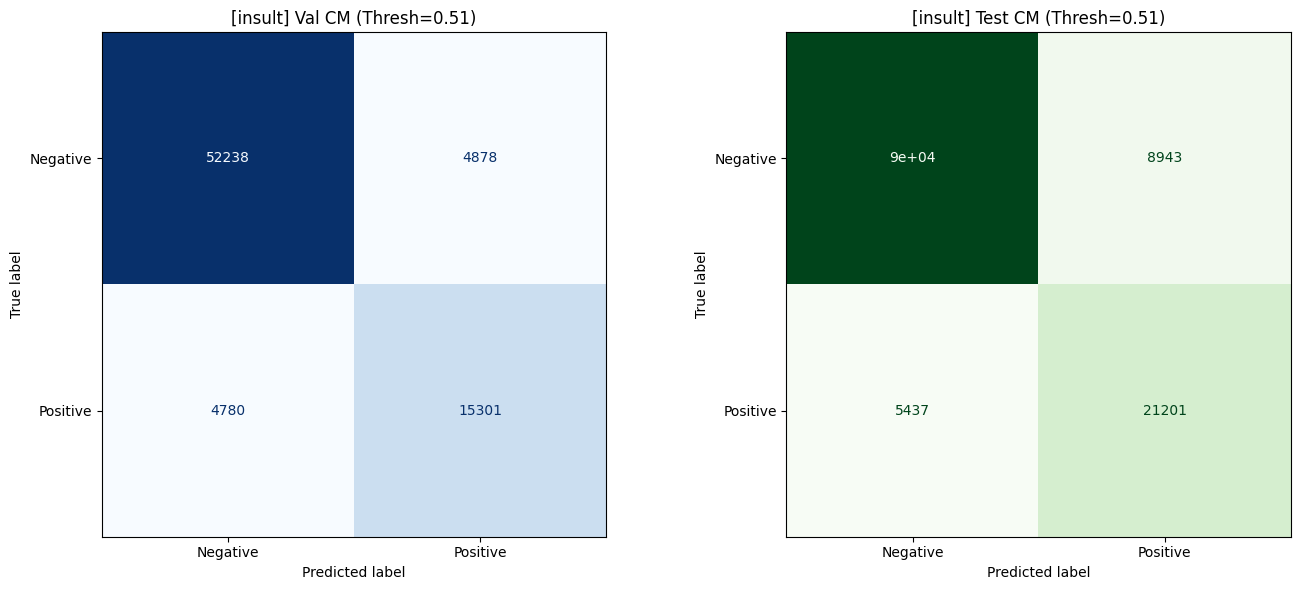


🔍 ANALYZING CLASS: THREAT

Metrics Table for threat (Filtered Subset):
Threshold  TP    FP    TN  FN
     0.00 641 76556     0   0
     0.05 633 41041 35515   8
     0.10 581  9845 66711  60
     0.15 494  3502 73054 147
     0.20 417  1846 74710 224
     0.25 352  1024 75532 289
     0.30 273   587 75969 368
     0.35 213   301 76255 428
     0.40 168   162 76394 473
     0.45 129    96 76460 512
     0.50  90    51 76505 551
     0.55  64    27 76529 577
     0.60  50    13 76543 591
     0.65  32     5 76551 609
     0.70  17     4 76552 624
     0.75  10     0 76556 631
     0.80   3     0 76556 638
     0.85   2     0 76556 639
     0.90   1     0 76556 640
     0.95   0     0 76556 641
     1.00   0     0 76556 641


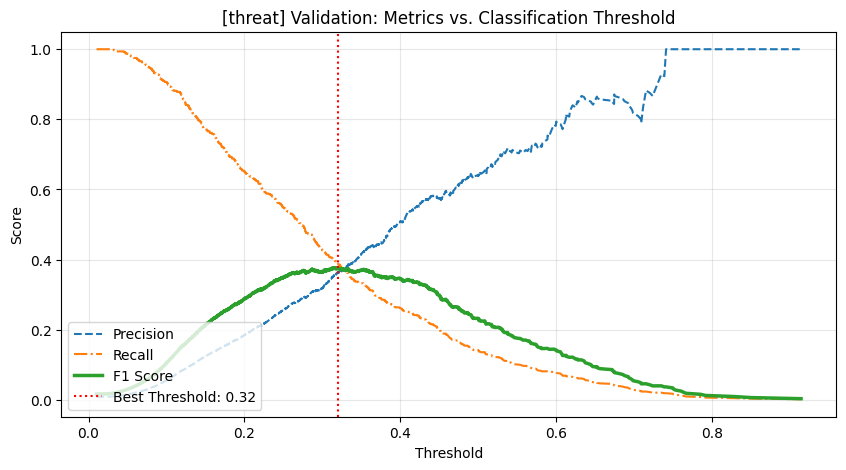


✅ Optimal F1 Threshold for threat: 0.32


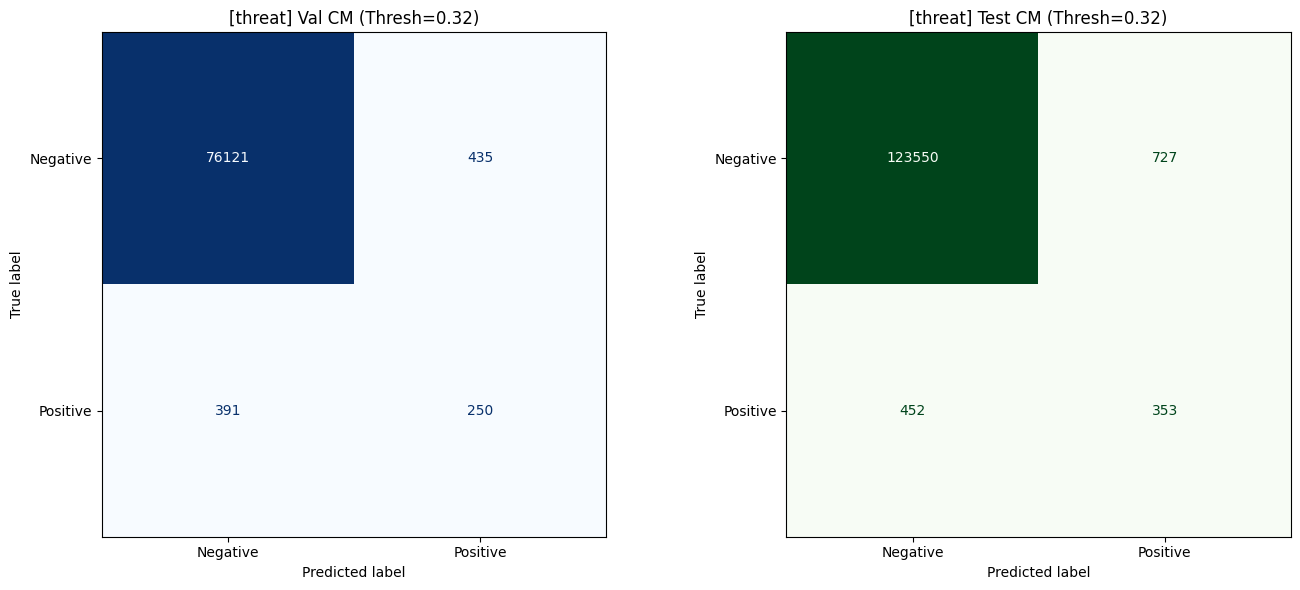


--- Final Optimal Thresholds Dictionary (Model 2) ---
{'obscene': 0.41440454, 'sexual_explicit': 0.35424402, 'identity_attack': 0.45023, 'insult': 0.51208633, 'threat': 0.32002267}


In [6]:
# =========================================================
# 3. MAIN EXECUTION
# =========================================================
if __name__ == "__main__":
    # 1. Configuration
    TEXT_COL = 'comment_text'
    TOXIC_COL = 'toxicity'
    # Define Sub-labels only (Model 2 targets)
    SUB_COLS = ['obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']
    
    print("Loading data...")
    train_df = pd.read_csv("data/input/train_split.csv").fillna({TEXT_COL: "missing_text"})
    val_df = pd.read_csv("data/input/val_split.csv").fillna({TEXT_COL: "missing_text"})
    test_df = pd.read_csv("data/input/test_split.csv").fillna({TEXT_COL: "missing_text"})

    train_df[TEXT_COL] = train_df[TEXT_COL].map(clean_text)
    val_df[TEXT_COL] = val_df[TEXT_COL].map(clean_text)
    test_df[TEXT_COL] = test_df[TEXT_COL].map(clean_text)

    # Base arrays
    X_train = train_df[TEXT_COL].to_numpy(dtype=object)
    X_val = val_df[TEXT_COL].to_numpy(dtype=object)
    X_test = test_df[TEXT_COL].to_numpy(dtype=object)
    
    # ==========================================
    # STAGE 1: TRAIN MODEL 1 (FILTER)
    # ==========================================
    neg_count = (train_df[TOXIC_COL] == 0).sum()
    pos_count = (train_df[TOXIC_COL] == 1).sum()
    initial_bias_v1 = np.log([(pos_count + 1e-7) / (neg_count + 1e-7)])
    
    print("\n🚀 [STAGE 1] Training Model 1 (Binary Toxicity Filter)...")
    model_v1 = build_bilstm_pipeline(train_texts=X_train, num_classes=1, initial_bias=initial_bias_v1, use_meta_features=False)
    
    early_stopping = callbacks.EarlyStopping(monitor='val_auc', verbose=1, patience=5, mode='max', restore_best_weights=True)
    
    model_v1.fit(
        x=X_train, y=train_df[TOXIC_COL].to_numpy(),
        batch_size=256, epochs=30, callbacks=[early_stopping],
        validation_data=(X_val, val_df[TOXIC_COL].to_numpy())
    )
    
    # ==========================================
    # STAGE 2: DUAL-THRESHOLD FILTERING & META FEATURES
    # ==========================================
    print("\n--- Generating Model 1 Predictions ---")
    train_probs_v1 = model_v1.predict(X_train, batch_size=256).flatten()
    val_probs_v1 = model_v1.predict(X_val, batch_size=256).flatten()
    test_probs_v1 = model_v1.predict(X_test, batch_size=256).flatten()
    
    # 1. Get the Optimal F1 Threshold (for the binary feature)
    print("\n--- Model 1 Optimal F1 Threshold Analysis ---")
    optimal_f1_thresh = plot_threshold_curves(val_df[TOXIC_COL], val_probs_v1, class_name="Model 1 Toxicity", dataset_name="Validation")
    print(f"✅ Optimal F1 Threshold (used for Binary Meta-Feature): {optimal_f1_thresh:.4f}")

    # 2. Get the 95% Recall Threshold (for filtering the dataset)
    recall_95_thresh = get_target_recall_threshold(val_df[TOXIC_COL], val_probs_v1, target_recall=0.95)
    print(f"✅ Threshold for 95% Recall (used for Filtering Data): {recall_95_thresh:.4f}")
    
    # Create masks to pass data to Model 2 using the lenient 95% recall threshold
    train_mask = train_probs_v1 >= recall_95_thresh
    val_mask = val_probs_v1 >= recall_95_thresh
    test_mask = test_probs_v1 >= recall_95_thresh
    
    print(f"Passing {train_mask.sum()} / {len(train_df)} Train cases to Model 2")
    
    # Isolate Sub-Labels for Model 2
    Y_train_sub = train_df[train_mask][SUB_COLS].to_numpy()
    Y_val_sub = val_df[val_mask][SUB_COLS].to_numpy()
    Y_test_sub = test_df[test_mask][SUB_COLS].to_numpy()
    
    # Generate Meta Features: [Continuous Probability, Binary Label based on Optimal F1 Threshold]
    meta_train = np.column_stack((
        train_probs_v1[train_mask], 
        (train_probs_v1[train_mask] >= optimal_f1_thresh).astype(float)
    ))
    meta_val = np.column_stack((
        val_probs_v1[val_mask], 
        (val_probs_v1[val_mask] >= optimal_f1_thresh).astype(float)
    ))
    meta_test = np.column_stack((
        test_probs_v1[test_mask], 
        (test_probs_v1[test_mask] >= optimal_f1_thresh).astype(float)
    ))
    
    X_train_sub = X_train[train_mask]
    X_val_sub = X_val[val_mask]
    X_test_sub = X_test[test_mask]
    
    # ==========================================
    # STAGE 3: TRAIN MODEL 2 (MULTI-LABEL + META FEATURES)
    # ==========================================
    initial_biases_v2 = []
    for i, col in enumerate(SUB_COLS):
        pos = (Y_train_sub[:, i] == 1).sum()
        neg = (Y_train_sub[:, i] == 0).sum()
        bias = np.log((pos + 1e-7) / (neg + 1e-7))
        initial_biases_v2.append(bias)
        
    print("\n🚀 [STAGE 3] Training Model 2 (Sub-labels with Multi-Input)...")
    model_v2 = build_bilstm_pipeline(
        train_texts=X_train_sub, 
        num_classes=len(SUB_COLS), 
        initial_bias=np.array(initial_biases_v2), 
        use_meta_features=True
    )
    
    model_v2.fit(
        x=[X_train_sub, meta_train], y=Y_train_sub,
        batch_size=256, epochs=30, callbacks=[early_stopping],
        validation_data=([X_val_sub, meta_val], Y_val_sub)
    )
    
    # ==========================================
    # STAGE 4: EVALUATE MODEL 2 (CLASS BY CLASS)
    # ==========================================
    print("\n--- Generating Model 2 Sub-Label Predictions ---")
    val_probs_v2 = model_v2.predict([X_val_sub, meta_val], batch_size=256)
    test_probs_v2 = model_v2.predict([X_test_sub, meta_test], batch_size=256)
    
    optimal_thresholds = {}

    for i, class_name in enumerate(SUB_COLS):
        print(f"\n{'='*50}")
        print(f"🔍 ANALYZING CLASS: {class_name.upper()}")
        print(f"{'='*50}")
        
        y_val_true_class = Y_val_sub[:, i]
        y_val_probs_class = val_probs_v2[:, i]
        y_test_true_class = Y_test_sub[:, i]
        y_test_probs_class = test_probs_v2[:, i]
        
        val_metrics_table = create_threshold_metrics_table(y_val_true_class, y_val_probs_class, step=0.05)
        print(f"\nMetrics Table for {class_name} (Filtered Subset):")
        print(val_metrics_table.to_string(index=False))
        
        best_thresh = plot_threshold_curves(y_val_true_class, y_val_probs_class, class_name=class_name, dataset_name="Validation")
        optimal_thresholds[class_name] = best_thresh
        print(f"\n✅ Optimal F1 Threshold for {class_name}: {best_thresh:.2f}")
        
        plot_dual_confusion_matrix(
            y_val=y_val_true_class, y_val_probs=y_val_probs_class,
            y_test=y_test_true_class, y_test_probs=y_test_probs_class,
            class_name=class_name, threshold=best_thresh
        )

    print("\n--- Final Optimal Thresholds Dictionary (Model 2) ---")
    print(optimal_thresholds)

In [10]:
# ==========================================
# STAGE 5: SAVE MODELS & ARTIFACTS
# ==========================================
import json
import os

os.makedirs("models", exist_ok=True)

print("\n--- Saving Models and Artifacts ---")

# 1. Save Keras Models (Forcing 'tf' SavedModel directory format)
model_v1.save("models/two_tier_model_v1_label", save_format="tf")
model_v2.save("models/two_tier_model_v2_sublabels", save_format="tf")

# 2. Package all dynamically generated thresholds and labels
inference_artifacts = {
    "model_1_recall_95_thresh": float(recall_95_thresh),
    "model_1_optimal_f1_thresh": float(optimal_f1_thresh),
    "model_2_optimal_thresholds": {k: float(v) for k, v in optimal_thresholds.items()},
    "sub_cols": SUB_COLS
}

# 3. Save as JSON
with open("models/two_tier_inference_artifacts.json", "w") as f:
    json.dump(inference_artifacts, f, indent=4)
    
print("✅ Successfully saved models and thresholds to the 'models/' directory.")


--- Saving Models and Artifacts ---


INFO:tensorflow:Assets written to: models/two_tier_model_v1_label\assets


INFO:tensorflow:Assets written to: models/two_tier_model_v1_label\assets


INFO:tensorflow:Assets written to: models/two_tier_model_v2_sublabels\assets


INFO:tensorflow:Assets written to: models/two_tier_model_v2_sublabels\assets


✅ Successfully saved models and thresholds to the 'models/' directory.
